In [1]:
# 🧪 SystemProvider Log Expansion — FSMOutput + Output Detail Fields

import os, sys, json
import pandas as pd
from pathlib import Path

# 📁 Set up paths
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

LOG_PATH = Path("tests/backup/provider_logs.csv")
assert LOG_PATH.exists(), "❌ provider_logs.csv not found"

# 📥 Load log data
df = pd.read_csv(LOG_PATH)

# 🔍 Filter only SYSTEM provider logs
df_system = df[df["provider_type"] == "PROVIDER_TYPE.SYSTEM"].copy()

# 🧼 Safe JSON parse
def safe_json_parse(val):
    try:
        return json.loads(val) if isinstance(val, str) else {}
    except Exception:
        return {}

df_system["output_parsed"] = df_system["output"].apply(safe_json_parse)

# 🧩 Extract FSMOutputSchema fields
df_system["state"] = df_system["output_parsed"].apply(lambda x: x.get("state"))
df_system["previous_state"] = df_system["output_parsed"].apply(lambda x: x.get("previous_state"))
df_system["state_type"] = df_system["output_parsed"].apply(lambda x: x.get("state_type"))
df_system["decision"] = df_system["output_parsed"].apply(lambda x: x.get("decision"))
df_system["steps"] = df_system["output_parsed"].apply(lambda x: x.get("steps"))
df_system["max_steps"] = df_system["output_parsed"].apply(lambda x: x.get("max_steps"))
df_system["summary"] = df_system["output_parsed"].apply(lambda x: x.get("summary"))
df_system["fsm_output"] = df_system["output_parsed"].apply(lambda x: x.get("output"))
df_system["provider_name"] = df_system["output_parsed"].apply(lambda x: x.get("provider_name"))

# 🧬 Expand fsm_output structure
df_system["fsm_file_path"] = df_system["fsm_output"].apply(lambda x: x.get("file_path") if isinstance(x, dict) else None)
df_system["fsm_reason"] = df_system["fsm_output"].apply(lambda x: x.get("reason") if isinstance(x, dict) else None)
df_system["fsm_retry_count"] = df_system["fsm_output"].apply(lambda x: x.get("retry_count") if isinstance(x, dict) else None)
df_system["fsm_last_state"] = df_system["fsm_output"].apply(lambda x: x.get("_last_state") if isinstance(x, dict) else None)
df_system["fsm_output_steps"] = df_system["fsm_output"].apply(lambda x: x.get("steps") if isinstance(x, dict) else None)

# 📐 Select final columns
feature_cols = [
    "timestamp", "provider_id", "file_log_id", "run_id",
    "state", "previous_state", "state_type", "decision", "steps", "max_steps",
    "latency_ms", "provider_name", "summary",
    "fsm_file_path", "fsm_reason", "fsm_retry_count", "fsm_last_state", "fsm_output_steps"
]

df_system_view = df_system[feature_cols].sort_values("timestamp")

pd.set_option("display.max_colwidth", 200)
df_system_view.head(20)


,timestamp,provider_id,file_log_id,run_id,state,previous_state,state_type,decision,steps,max_steps,latency_ms,provider_name,summary,fsm_file_path,fsm_reason,fsm_retry_count,fsm_last_state,fsm_output_steps
54,2025-06-16 04:00:05.382844+00:00,1,1,6663b539-0311-4b33-8536-6e827e92a29d,end,code_stability,end,accepted,7,7,8687,linting_system_provider,Completed,working_files\temp_sys_2300140680.py,custom_rule,0,code_stability,7
127,2025-06-16 04:00:16.777069+00:00,1,2,9ddff57b-9b29-4d24-afbc-ea9453b2a0d7,end,code_stability,end,accepted,7,7,9755,linting_system_provider,Completed,working_files\temp_sys_2300265289.py,custom_rule,0,code_stability,7
200,2025-06-16 04:00:29.689497+00:00,1,3,78c7d072-bf4c-4486-8ae2-648bd59642e6,end,code_stability,end,accepted,7,7,9995,linting_system_provider,Completed,working_files\temp_sys_2300396828.py,custom_rule,0,code_stability,7
273,2025-06-16 04:00:42.724452+00:00,1,4,a224e963-e6d8-4edb-97e0-6384eb4212c4,end,code_stability,end,accepted,7,7,9875,linting_system_provider,Completed,working_files\temp_sys_2300525977.py,custom_rule,0,code_stability,7
346,2025-06-16 04:00:55.683128+00:00,1,5,4b3cb018-af1e-49bb-82d2-1b9a230d7f8a,end,code_stability,end,accepted,7,7,9713,linting_system_provider,Completed,working_files\temp_sys_2301053943.py,custom_rule,0,code_stability,7
419,2025-06-16 04:01:08.429367+00:00,1,6,897a292a-2ea9-4f5b-bd75-40b71575a141,end,code_stability,end,accepted,7,7,9857,linting_system_provider,Completed,working_files\temp_sys_2301182823.py,custom_rule,0,code_stability,7
492,2025-06-16 04:01:21.475616+00:00,1,7,9122641c-744e-4b62-9641-999b5d210abb,end,code_stability,end,accepted,7,7,9707,linting_system_provider,Completed,working_files\temp_sys_2301311811.py,custom_rule,0,code_stability,7
565,2025-06-16 04:01:34.207698+00:00,1,8,54d29b74-6374-4b28-8c91-6b0f52cf7919,end,code_stability,end,accepted,7,7,9637,linting_system_provider,Completed,working_files\temp_sys_2301438430.py,custom_rule,0,code_stability,7
638,2025-06-16 04:01:46.980304+00:00,1,9,aa4b1251-d4d8-42d2-9e7d-149b1ff3c29a,end,code_stability,end,accepted,7,7,9486,linting_system_provider,Completed,working_files\temp_sys_2301564652.py,custom_rule,0,code_stability,7
711,2025-06-16 04:01:59.733955+00:00,1,10,58f78181-d310-4471-b914-205507174c92,end,code_stability,end,accepted,7,7,10264,linting_system_provider,Completed,working_files\temp_sys_2302099970.py,custom_rule,0,code_stability,7


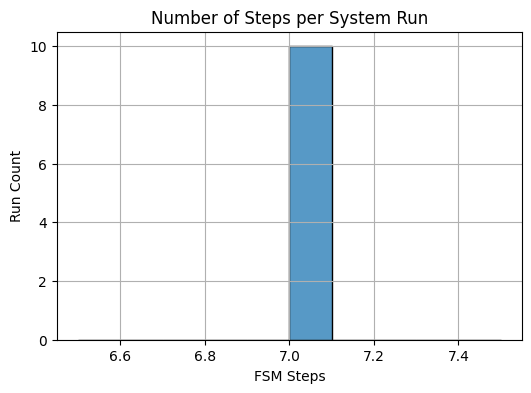

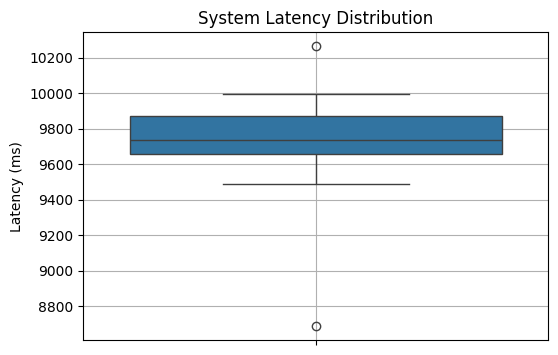

In [2]:
# 📈 Distribution of Steps and Latency for System Runs

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of FSM steps
plt.figure(figsize=(6, 4))
sns.histplot(df_system_view["steps"], bins=10, kde=False)
plt.title("Number of Steps per System Run")
plt.xlabel("FSM Steps")
plt.ylabel("Run Count")
plt.grid(True)
plt.show()

# Latency distribution
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_system_view, y="latency_ms")
plt.title("System Latency Distribution")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.show()


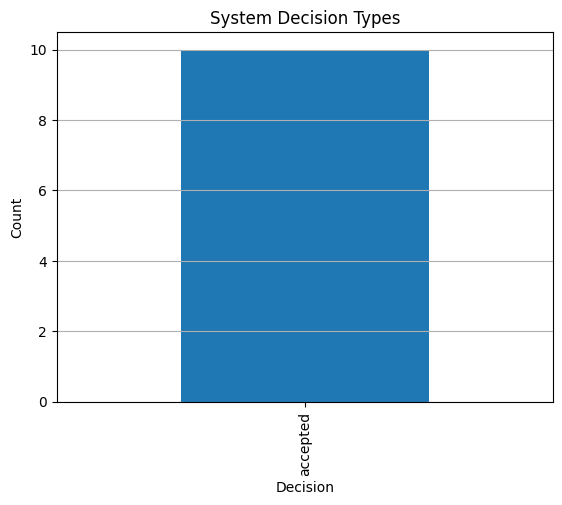

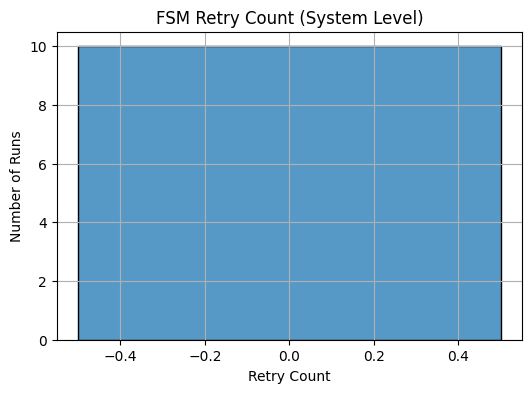

In [3]:
# 📊 Decision Type Breakdown and Retry Count Histogram for Systems

# Decision counts
decision_counts = df_system_view["decision"].value_counts().sort_index()
decision_counts.plot(kind="bar", title="System Decision Types", ylabel="Count", xlabel="Decision")
plt.grid(axis='y')
plt.show()

# Retry count distribution
plt.figure(figsize=(6, 4))
sns.histplot(df_system_view["fsm_retry_count"], bins=5, discrete=True)
plt.title("FSM Retry Count (System Level)")
plt.xlabel("Retry Count")
plt.ylabel("Number of Runs")
plt.grid(True)
plt.show()
